In [ ]:
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F

# Initialize Spark Session
spark = SparkSession.builder.appName("AgroPulse_Preprocessing").getOrCreate()

# Load data
df = spark.read.csv("/content/sample_data/AgroPulse_Updated_Data.csv", header=True, inferSchema=True)

# 1. Convert Date column to DateType
df = df.withColumn("Date", F.to_date("Date"))

# 2. Linear Interpolation Function for Radar_VV and Mean_NDVI
# This logic finds the closest previous and next non-null values to calculate the slope
def interpolate_column(df, col_name):
    window_bwd = Window.orderBy("Date").rowsBetween(Window.unboundedPreceding, 0)
    window_fwd = Window.orderBy("Date").rowsBetween(0, Window.unboundedFollowing)

    # Get previous non-null value and its date
    df = df.withColumn("prev_val", F.last(col_name, ignorenulls=True).over(window_bwd)) \
           .withColumn("prev_date", F.last(F.when(F.col(col_name).isNotNull(), F.col("Date")), ignorenulls=True).over(window_bwd))

    # Get next non-null value and its date
    df = df.withColumn("next_val", F.first(col_name, ignorenulls=True).over(window_fwd)) \
           .withColumn("next_date", F.first(F.when(F.col(col_name).isNotNull(), F.col("Date")), ignorenulls=True).over(window_fwd))

    # Calculate interpolated value: y = y0 + (y1 - y0) * ( (x - x0) / (x1 - x0) )
    df = df.withColumn(col_name,
        F.when(F.col(col_name).isNotNull(), F.col(col_name))
        .otherwise(
            F.col("prev_val") + (F.col("next_val") - F.col("prev_val")) * (F.datediff(F.col("Date"), F.col("prev_date")) / F.datediff(F.col("next_date"), F.col("prev_date")))
        )
    ).drop("prev_val", "prev_date", "next_val", "next_date")

    return df

# Apply interpolation to Radar_VV and Mean_NDVI
df = interpolate_column(df, "Radar_VV")
df = interpolate_column(df, "Mean_NDVI")

# 3. Handle missing values in Max_Future_Water (forward fill)
window_ffill = Window.orderBy("Date").rowsBetween(Window.unboundedPreceding, 0)
df = df.withColumn("Max_Future_Water", F.last("Max_Future_Water", ignorenulls=True).over(window_ffill))

# 4. Final Clean up (Example: Ensuring integer types for status)
df = df.withColumn("AgroPulse_Status", F.col("AgroPulse_Status").cast("int"))

# Preview the results
df.select("Date", "Radar_VV", "Mean_NDVI", "Max_Future_Water").show(15)

+----------+-------------------+-------------------+----------------+
|      Date|           Radar_VV|          Mean_NDVI|Max_Future_Water|
+----------+-------------------+-------------------+----------------+
|2016-01-01| -12.34963018864365|  0.276900405796415|             4.1|
|2016-01-02| -12.34963018864365|0.27694331201432953|             4.1|
|2016-01-03|-12.349630188643648|0.27698621823224406|             4.1|
|2016-01-04|-12.349630188643648|0.27702912445015854|             4.1|
|2016-01-05|-12.349630188643646|0.27707203066807307|             4.1|
|2016-01-06|-12.349630188643646| 0.2771149368859876|             4.1|
|2016-01-07|-12.264832368621072|0.27325611701599123|             4.1|
|2016-01-08|-12.180034548598496|0.26939729714599486|             4.1|
|2016-01-09|-12.095236728575921|0.26553847727599855|             4.1|
|2016-01-10|-12.010438908553345| 0.2616796574060022|             4.1|
|2016-01-11| -11.92564108853077| 0.2578208375360058|             4.1|
|2016-01-12| -11.790

In [ ]:
df = df.drop("Max_Future_Water")

In [ ]:
df.show()

+----------+---------------------+---------------------+-------------------+-------------------+-----------------+------------------+------------------+--------------+------------+----------------+
|      Date|Rain_Sunamganj_Center|Rain_Meghalaya_Border|          Mean_NDVI|           Radar_VV|Daily_Water_Level|        NDVI_Clean|     NDVI_7Day_Avg|Flood_In_7Days|  Crop_State|AgroPulse_Status|
+----------+---------------------+---------------------+-------------------+-------------------+-----------------+------------------+------------------+--------------+------------+----------------+
|2016-01-01|                  0.0|                  0.0|  0.276900405796415| -12.34963018864365|              4.1| 0.276900405796415| 0.276900405796415|             0|Post-Harvest|               0|
|2016-01-02|                  0.0|   0.1199070848787284|0.27694331201432953| -12.34963018864365|              4.1| 0.276900405796415| 0.276900405796415|             0|Post-Harvest|               0|
|2016-01-0

In [ ]:
# 2. Load the New Features
df_new = spark.read.csv("/content/sample_data/sunamganj_climate_2016_2025_5day(feature).csv", header=True, inferSchema=True)
df_new = df_new.withColumn("Date", F.to_date("Date"))

# 3. Rename columns
df_new = df_new.withColumnRenamed("Soil_Moisture", "Soil_Moisture") \
               .withColumnRenamed("Temperature_C", "Temperature")

# 4. Join the datasets
df_final = df.join(df_new, on="Date", how="left")

# 5. Handle missing values (Interpolate/Forward Fill)
from pyspark.sql.window import Window
window_spec = Window.orderBy("Date").rowsBetween(Window.unboundedPreceding, 0)

df_final = df_final.withColumn("Soil_Moisture", F.last("Soil_Moisture", ignorenulls=True).over(window_spec))
df_final = df_final.withColumn("Temperature", F.last("Temperature", ignorenulls=True).over(window_spec))

# 6. Save the final multi-modal dataset
# Note: df_final now contains the interpolated 'Radar_VV' column
df_final.write.csv("AgroPulse_Final_Training_Set.csv", header=True, mode="overwrite")

print("✅ Successfully merged Soil Moisture and Temperature!")
# Corrected selection below:
df_final.select("Date", "NDVI_Clean", "Radar_VV", "Soil_Moisture", "Temperature").show(5)

✅ Successfully merged Soil Moisture and Temperature!
+----------+-----------------+-------------------+-------------+-----------+
|      Date|       NDVI_Clean|           Radar_VV|Soil_Moisture|Temperature|
+----------+-----------------+-------------------+-------------+-----------+
|2016-01-01|0.276900405796415| -12.34963018864365|        0.168|      18.56|
|2016-01-02|0.276900405796415| -12.34963018864365|        0.168|      18.56|
|2016-01-03|0.276900405796415|-12.349630188643648|        0.168|      18.56|
|2016-01-04|0.276900405796415|-12.349630188643648|        0.168|      18.56|
|2016-01-05|0.276900405796415|-12.349630188643646|        0.168|      18.56|
+----------+-----------------+-------------------+-------------+-----------+
only showing top 5 rows


In [ ]:
df_final.show()

+----------+---------------------+---------------------+-------------------+-------------------+-----------------+------------------+------------------+--------------+------------+----------------+-----------+-------------+
|      Date|Rain_Sunamganj_Center|Rain_Meghalaya_Border|          Mean_NDVI|           Radar_VV|Daily_Water_Level|        NDVI_Clean|     NDVI_7Day_Avg|Flood_In_7Days|  Crop_State|AgroPulse_Status|Temperature|Soil_Moisture|
+----------+---------------------+---------------------+-------------------+-------------------+-----------------+------------------+------------------+--------------+------------+----------------+-----------+-------------+
|2016-01-01|                  0.0|                  0.0|  0.276900405796415| -12.34963018864365|              4.1| 0.276900405796415| 0.276900405796415|             0|Post-Harvest|               0|      18.56|        0.168|
|2016-01-02|                  0.0|   0.1199070848787284|0.27694331201432953| -12.34963018864365|        

In [ ]:
from pyspark.sql import functions as F

# 1. Define your Precise Flood Indicator
# Conditions: High Water Level AND Low Radar Backscatter AND Saturated Soil
df_final = df_final.withColumn(
    "Precise_Flood_Indicator",
    F.when(
        (F.col("Daily_Water_Level") >= 7) &
        (F.col("Radar_VV") < -16) &
        (F.col("Soil_Moisture") >= 0.40), # Use 0.40 for decimal or 80 for %
        1
    ).otherwise(0)
)

# 2. Preview the results to see if they align with historical flood dates
df_final.select(
    "Date",
    "Daily_Water_Level",
    "Radar_VV",
    "Soil_Moisture",
    "Precise_Flood_Indicator"
).where(F.col("Precise_Flood_Indicator") == 1).show(10)

+----------+-----------------+-------------------+-------------+-----------------------+
|      Date|Daily_Water_Level|           Radar_VV|Soil_Moisture|Precise_Flood_Indicator|
+----------+-----------------+-------------------+-------------+-----------------------+
|2016-07-04|            7.204|-16.376418542217113|        0.436|                      1|
|2016-07-05|            7.204|-16.484205100485738|        0.436|                      1|
|2016-07-06|            7.204|-16.591991658754367|        0.436|                      1|
|2016-07-07|            7.204|-16.699778217022992|        0.436|                      1|
|2016-07-08|            7.204| -16.80756477529162|        0.436|                      1|
|2016-07-09|            7.204|-16.915351333560245|        0.433|                      1|
|2016-07-10|            7.204| -16.94382740108392|        0.433|                      1|
|2016-07-11|            7.204|-16.972303468607596|        0.433|                      1|
|2016-07-12|         

In [ ]:
df_final.show()

+----------+---------------------+---------------------+-------------------+-------------------+-----------------+------------------+------------------+--------------+------------+----------------+-----------+-------------+-----------------------+
|      Date|Rain_Sunamganj_Center|Rain_Meghalaya_Border|          Mean_NDVI|           Radar_VV|Daily_Water_Level|        NDVI_Clean|     NDVI_7Day_Avg|Flood_In_7Days|  Crop_State|AgroPulse_Status|Temperature|Soil_Moisture|Precise_Flood_Indicator|
+----------+---------------------+---------------------+-------------------+-------------------+-----------------+------------------+------------------+--------------+------------+----------------+-----------+-------------+-----------------------+
|2016-01-01|                  0.0|                  0.0|  0.276900405796415| -12.34963018864365|              4.1| 0.276900405796415| 0.276900405796415|             0|Post-Harvest|               0|      18.56|        0.168|                      0|
|2016-01

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# 1. Calculate NDVI Slope (5-day trend)
window_spec = Window.orderBy("Date")
df_final = df_final.withColumn("NDVI_Slope", F.col("NDVI_Clean") - F.lag("NDVI_Clean", 1).over(window_spec))

# 2. Advanced Multi-Modal Classification Logic
df_final = df_final.withColumn("Refined_Crop_State",
    # --- GROWING ---
    # Rule 1: High NDVI (> 0.58) AND positive slope (actively greening up)
    # Rule 2: Low NDVI but High Soil Moisture (Transplanting phase)
    F.when(
        ((F.col("NDVI_Clean") > 0.58) & (F.col("NDVI_Slope") > 0)) |
        ((F.col("NDVI_Clean") < 0.30) & (F.col("Soil_Moisture") > 0.40)),
        "Growing"
    )
    # --- MATURE ---
    # Rule 1: NDVI is in the mid-range (0.30 - 0.58)
    # Rule 2: High NDVI (> 0.58) but negative slope (Senescence/Ripening has started)
    .when(
        (F.col("NDVI_Clean").between(0.30, 0.58)) |
        ((F.col("NDVI_Clean") > 0.58) & (F.col("NDVI_Slope") <= 0)),
        "Mature"
    )
    # --- POST-HARVEST ---
    # Rule: Low NDVI (< 0.30) and Soil is dry
    .when(
        (F.col("NDVI_Clean") < 0.30) & (F.col("Soil_Moisture") <= 0.40),
        "Post_Harvest"
    )
    # Default fallback
    .otherwise("Post_Harvest")
)

# 3. Final selection and check
df_final.select(
    "Date",
    "NDVI_Clean",
    "NDVI_Slope",
    "Soil_Moisture",
    "Refined_Crop_State"
).show(15)

+----------+------------------+--------------------+-------------+------------------+
|      Date|        NDVI_Clean|          NDVI_Slope|Soil_Moisture|Refined_Crop_State|
+----------+------------------+--------------------+-------------+------------------+
|2016-01-01| 0.276900405796415|                NULL|        0.168|      Post_Harvest|
|2016-01-02| 0.276900405796415|                 0.0|        0.168|      Post_Harvest|
|2016-01-03| 0.276900405796415|                 0.0|        0.168|      Post_Harvest|
|2016-01-04| 0.276900405796415|                 0.0|        0.168|      Post_Harvest|
|2016-01-05| 0.276900405796415|                 0.0|        0.168|      Post_Harvest|
|2016-01-06|0.2771149368859876|2.145310895725893...|        0.163|      Post_Harvest|
|2016-01-07|0.2771149368859876|                 0.0|        0.163|      Post_Harvest|
|2016-01-08|0.2771149368859876|                 0.0|        0.163|      Post_Harvest|
|2016-01-09|0.2771149368859876|                 0.0|  

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# 1. Setup Window and Slope
window_spec = Window.orderBy("Date")
df_final = df_final.withColumn("NDVI_Slope", F.col("NDVI_Clean") - F.lag("NDVI_Clean", 1).over(window_spec))

# 2. Re-apply the Precise_Flood_Indicator (based on your validated thresholds)
df_final = df_final.withColumn("Precise_Flood_Indicator",
    F.when(
        (F.col("Daily_Water_Level") >= 7) &
        (F.col("Radar_VV") < -16) &
        (F.col("Soil_Moisture") >= 0.40), 1
    ).otherwise(0)
)

# 3. Re-apply the Refined_Crop_State (based on your 0.60/0.30 thresholds)
df_final = df_final.withColumn("Refined_Crop_State",
    F.when((F.col("NDVI_Clean") > 0.60) | ((F.col("NDVI_Clean") < 0.30) & (F.col("Soil_Moisture") > 0.40)), "Growing")
     .when(F.col("NDVI_Clean").between(0.30, 0.60), "Mature")
     .when((F.col("NDVI_Clean") < 0.30) & (F.col("Soil_Moisture") <= 0.40), "Post_Harvest")
     .otherwise("Mature")
)

# 4. CREATE THE FINAL LEVEL (The Smart Status)
 #MERGED VERSION (recommended)
df_final = df_final.withColumn(
    "Final_AgroPulse_Level",

    # Level 0: Safe
    F.when(F.col("Precise_Flood_Indicator") == 0, 0)

    # Level 1: Moderate / Harvest-Risk
    # Merging Post_Harvest + Growing
    .when(
        (F.col("Precise_Flood_Indicator") == 1) &
        (F.col("Refined_Crop_State").isin("Post_Harvest", "Growing")),
        1
    )

    # Level 2: Critical Flood + Mature Crop
    .when(
        (F.col("Precise_Flood_Indicator") == 1) &
        (F.col("Refined_Crop_State") == "Mature"),
        2
    )

    .otherwise(0)
)

# Preview the Final Intelligence
df_final.select(
    "Date",
    "Refined_Crop_State",
    "Precise_Flood_Indicator",
    "Final_AgroPulse_Level"
).where(F.col("Final_AgroPulse_Level") > 0).show(10)

+----------+------------------+-----------------------+---------------------+
|      Date|Refined_Crop_State|Precise_Flood_Indicator|Final_AgroPulse_Level|
+----------+------------------+-----------------------+---------------------+
|2016-07-04|           Growing|                      1|                    1|
|2016-07-05|           Growing|                      1|                    1|
|2016-07-06|           Growing|                      1|                    1|
|2016-07-07|           Growing|                      1|                    1|
|2016-07-08|           Growing|                      1|                    1|
|2016-07-09|           Growing|                      1|                    1|
|2016-07-10|           Growing|                      1|                    1|
|2016-07-11|           Growing|                      1|                    1|
|2016-07-12|           Growing|                      1|                    1|
|2016-07-13|           Growing|                      1|         

In [ ]:
df_final.show()

+----------+---------------------+---------------------+------------------+-------------------+-----------------+------------------+------------------+--------------+------------+----------------+-----------+-------------+--------------------+-----------------------+------------------+---------------------+
|      Date|Rain_Sunamganj_Center|Rain_Meghalaya_Border|         Mean_NDVI|           Radar_VV|Daily_Water_Level|        NDVI_Clean|     NDVI_7Day_Avg|Flood_In_7Days|  Crop_State|AgroPulse_Status|Temperature|Soil_Moisture|          NDVI_Slope|Precise_Flood_Indicator|Refined_Crop_State|Final_AgroPulse_Level|
+----------+---------------------+---------------------+------------------+-------------------+-----------------+------------------+------------------+--------------+------------+----------------+-----------+-------------+--------------------+-----------------------+------------------+---------------------+
|2016-01-01|                  0.0|                  0.0| 0.27690040579641

In [ ]:
df_final.write.csv("/content/sample_data/AgroPulse_Final_Training_Set1111.csv", header=True)
print("✅ Final Dataset Ready for Model Training!")

✅ Final Dataset Ready for Model Training!


✅ Final Dataset Ready for Model Training!


In [ ]:
# Count the occurrences of each level
class_counts = df_final.groupBy("Final_AgroPulse_Level").count().orderBy("Final_AgroPulse_Level")

# Show the distribution
print("Final Dataset Class Distribution:")
class_counts.show()

# Optional: Calculate percentages to see the imbalance
total_rows = df_final.count()
class_counts.withColumn("Percentage", (F.col("count") / total_rows) * 100).show()

Final Dataset Class Distribution:
+---------------------+-----+
|Final_AgroPulse_Level|count|
+---------------------+-----+
|                    0| 3389|
|                    1|  250|
|                    2|   14|
+---------------------+-----+

+---------------------+-----+------------------+
|Final_AgroPulse_Level|count|        Percentage|
+---------------------+-----+------------------+
|                    0| 3389| 92.77306323569668|
|                    1|  250|  6.84369011771147|
|                    2|   14|0.3832466465918423|
+---------------------+-----+------------------+



**CNN and LSTM**

In [ ]:
!pip install tensorflow numpy pandas scikit-learn

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/sample_data/Agro_pulsedataset(verified).csv")

# Ensure correct sorting
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

In [ ]:
feature_cols = [
    "NDVI_Clean",                 # Crop condition
    "Rain_Sunamganj_Center",      # Local rainfall
    "Rain_Meghalaya_Border",      # Upstream rainfall (drives flash flood)
    "Daily_Water_Level",          # Ground + satellite fused level
    "Soil_Moisture",              # Crop stage + flood indicator
    "Temperature",                # Crop physiological development
    "Radar_VV"                    # Flood + waterlogging detection
]
target_col = "Final_AgroPulse_Level"

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. DROP any rows with NaNs in feature/target columns
df = df.dropna(subset=feature_cols + [target_col])

# 2. SCALE the features (Crucial for Conv1D and BatchNormalization)
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

# 3. ENSURE Target labels are contiguous (0, 1, 2)
# If your levels are 0, 1, 3 -> sparse_categorical_crossentropy will fail or Nan
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df[target_col] = le.fit_transform(df[target_col])

# Now create sequences as you did
X, y = create_sequences(df, feature_cols, target_col)

In [ ]:
SEQ_LEN = 7

def create_sequences(df, feature_cols, target_col, seq_len=SEQ_LEN):
    X, y = [], []
    data = df[feature_cols].values
    labels = df[target_col].values

    for i in range(len(df) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(labels[i+seq_len])

    return np.array(X), np.array(y)

X, y = create_sequences(df, feature_cols, target_col)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3281, 7, 7)
y shape: (3281,)


In [ ]:
from sklearn.model_selection import train_test_split

# STRATIFY is the secret to perfection here
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {i: w for i, w in enumerate(class_weights)}
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.36248100566376573), 1: np.float64(4.373333333333333), 2: np.float64(79.51515151515152)}


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

# Define the number of classes, which is derived from the 'classes' variable.
# The 'classes' variable contains the unique values in y_train.
num_classes = len(classes)

# 1. Simplify the architecture
model = models.Sequential([
    # Use Input layer to avoid warnings
    layers.Input(shape=(SEQ_LEN, len(feature_cols))),

    # One Conv layer is enough for very short sequences (SEQ_LEN ~7)
    # Using 'same' padding to keep the sequence from disappearing
    layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(), # Helps stabilize the 'NaN' and loss issues
    layers.MaxPooling1D(pool_size=2),

    # Flatten and use stronger Dropout to stop the overfitting you saw
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.5), # Increased from 0.3 to 0.5

    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 7, 32)          │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,035 (15.76 KB)

 Trainable params: 3,971 (15.51 KB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,             # Stops if val_loss doesn't improve for 5 epochs
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[callback],    # Add the callback here
    verbose=1
)

Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4212 - loss: 1.5765 - val_accuracy: 0.7215 - val_loss: 0.6959
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6840 - loss: 0.8534 - val_accuracy: 0.8082 - val_loss: 0.4717
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7459 - loss: 0.6008 - val_accuracy: 0.8280 - val_loss: 0.3820
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7973 - loss: 0.4045 - val_accuracy: 0.8356 - val_loss: 0.3559
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8090 - loss: 0.4565 - val_accuracy: 0.8478 - val_loss: 0.3232
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8171 - loss: 0.3882 - val_accuracy: 0.8737 - val_loss: 0.2678
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8505 - loss: 0.3761 - val_accuracy: 0.8356 - val_loss: 0.3405
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8479 - loss: 0.4688 - val_accuracy: 0.8935 - val_loss

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9441 - loss: 0.1131
Test Accuracy: 0.9512937664985657


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = np.argmax(model.predict(X_test), axis=1)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
[[575  29   0]
 [  3  47   0]
 [  0   0   3]]
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       604
           1       0.62      0.94      0.75        50
           2       1.00      1.00      1.00         3

    accuracy                           0.95       657
   macro avg       0.87      0.96      0.91       657
weighted avg       0.97      0.95      0.96       657



In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

# Define the number of classes, which is derived from the 'classes' variable.
# The 'classes' variable contains the unique values in y_train.
num_classes = len(classes)

# Use the dampened weights we found to balance precision and recall
final_weights = {
    0: 0.3624810056637657,    # Majority class (No Flood)
    1: 4.373333333333333,    # Minority class (Minor Flood)
    2: 79.51515151515152,    # Moderate

}

# Add EarlyStopping because LSTMs overfit faster than CNNs on small data
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

model_lstm = models.Sequential([
    layers.Input(shape=(SEQ_LEN, len(feature_cols))),

    # LSTM layer - units=64 is a good starting point
    layers.LSTM(64, return_sequences=False),

    layers.Dropout(0.4),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=64,
    class_weight=final_weights,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5190 - loss: 0.9767 - val_accuracy: 0.6301 - val_loss: 0.8909
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6373 - loss: 0.8394 - val_accuracy: 0.6484 - val_loss: 0.7873
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6675 - loss: 0.6751 - val_accuracy: 0.6819 - val_loss: 0.6740
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6807 - loss: 0.6677 - val_accuracy: 0.7336 - val_loss: 0.5563
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7479 - loss: 0.4829 - val_accuracy: 0.7823 - val_loss: 0.4613
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8168 - loss: 0.5216 - val_accuracy: 0.8508 - val_loss: 0.3491
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8717 - loss: 0.3542 - val_accuracy: 0.8402 - val_loss: 0.3354
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8684 - loss: 0.2499 - val_accuracy: 0.882

In [ ]:
# ১. মডেলটি .h5 ফরম্যাটে সেভ করুন
model_lstm.save('agropulse_lstm_model.h5')
print("Model saved successfully as .h5!")

# ২. Colab থেকে আপনার পিসিতে ডাউনলোড করুন
from google.colab import files
files.download('agropulse_lstm_model.h5')

Model saved successfully as .h5!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

LSTM CLASSIFICATION REPORT
                precision    recall  f1-score   support

      No Flood       1.00      0.96      0.98       604
   Minor Flood       0.67      0.96      0.79        50
Moderate Flood       0.75      1.00      0.86         3

      accuracy                           0.96       657
     macro avg       0.80      0.97      0.87       657
  weighted avg       0.97      0.96      0.96       657


Confusion matrix images saved as 'lstm_confusion_matrix.pdf' and '.png'


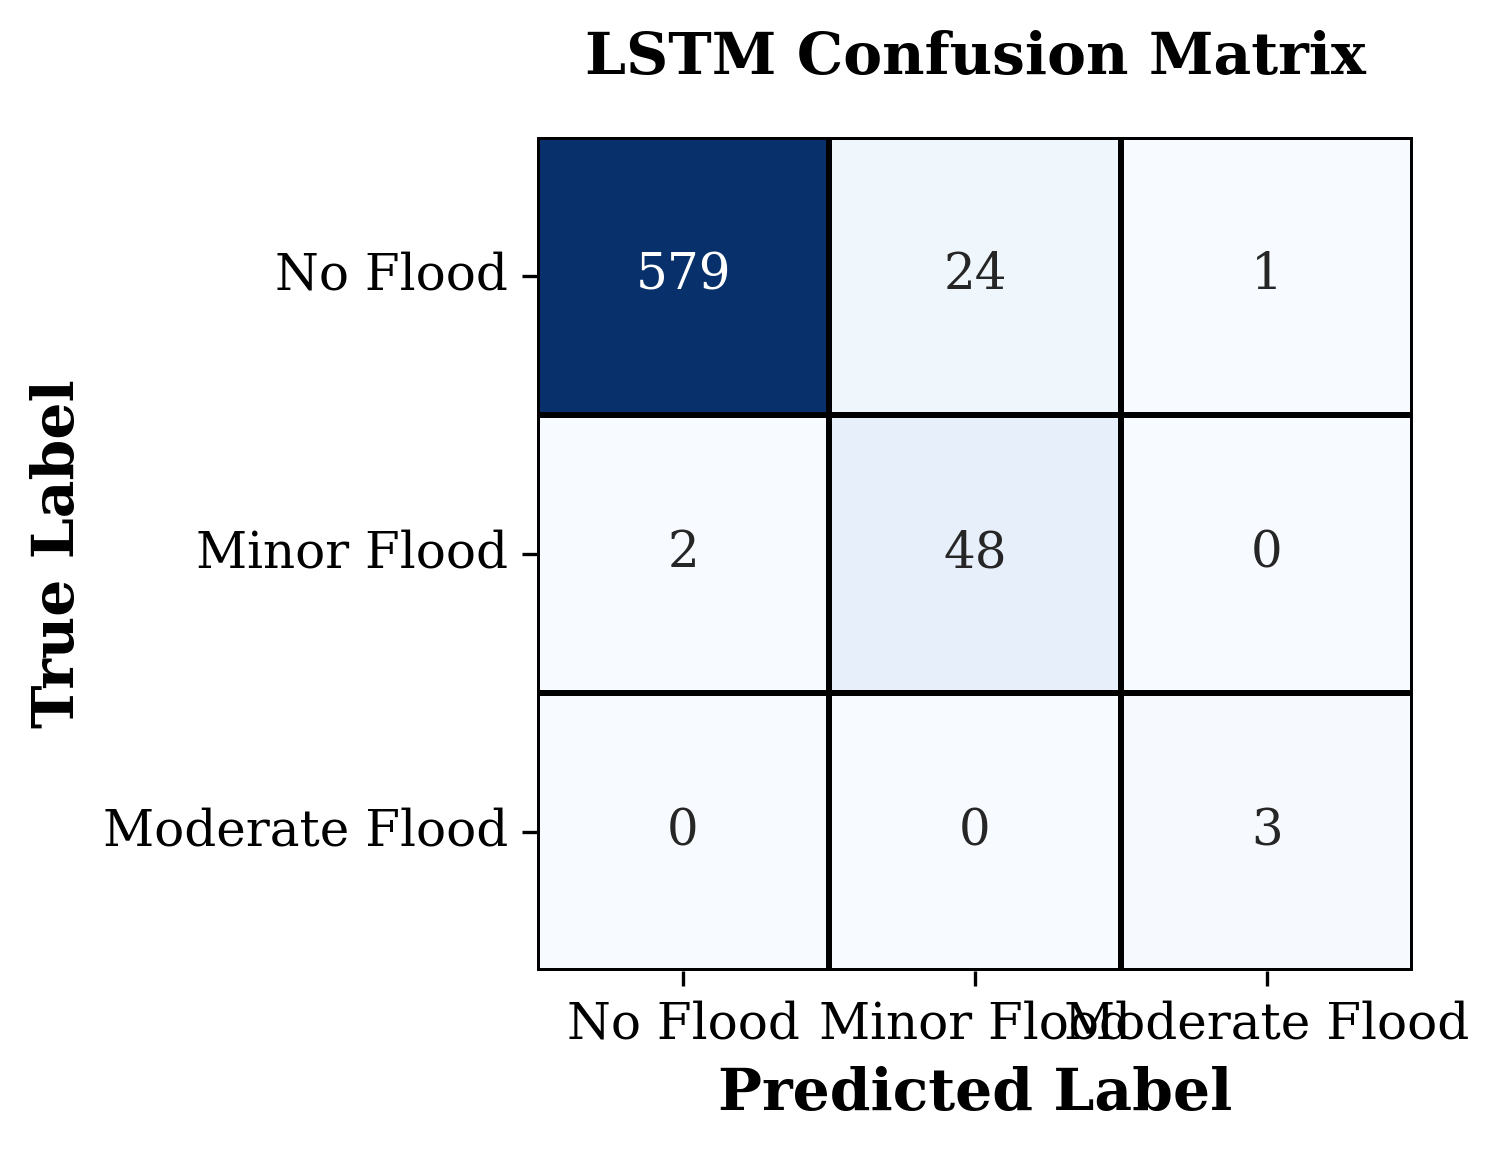

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. Generate Predictions ---
# The model outputs probabilities for each of the 3 classes.
y_pred_probs = model_lstm.predict(X_test)

# Convert probabilities to actual class labels (0, 1, or 2) by picking the highest probability
y_pred = np.argmax(y_pred_probs, axis=1)

# Define your class names based on your weights dictionary comments
class_names = ['No Flood', 'Minor Flood', 'Moderate Flood']

# --- 2. Print Classification Report ---
# This automatically calculates Precision, Recall, and F1-Score for each class & averages
print("\n" + "="*50)
print("LSTM CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred, target_names=class_names))

# --- 3. Generate Publication-Quality Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

# Set IEEE paper font styling
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'figure.dpi': 300
})

fig, ax = plt.subplots(figsize=(5, 4))

# Create the heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor='black', cbar=False, ax=ax)

# Add labels and title
ax.set_xlabel('Predicted Label', fontweight='bold')
ax.set_ylabel('True Label', fontweight='bold')
ax.set_title('LSTM Confusion Matrix', pad=15, fontweight='bold')

plt.tight_layout()

# Save high-resolution images for your paper
plt.savefig('lstm_confusion_matrix.pdf', dpi=300, bbox_inches='tight')
plt.savefig('lstm_confusion_matrix.png', dpi=300, bbox_inches='tight')

print("\nConfusion matrix images saved as 'lstm_confusion_matrix.pdf' and '.png'")
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_32
Received: inputs=['Tensor(shape=(100, 7, 7))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_32
Received: inputs=['Tensor(shape=(50, 7, 7))']
  warnings.warn(msg)


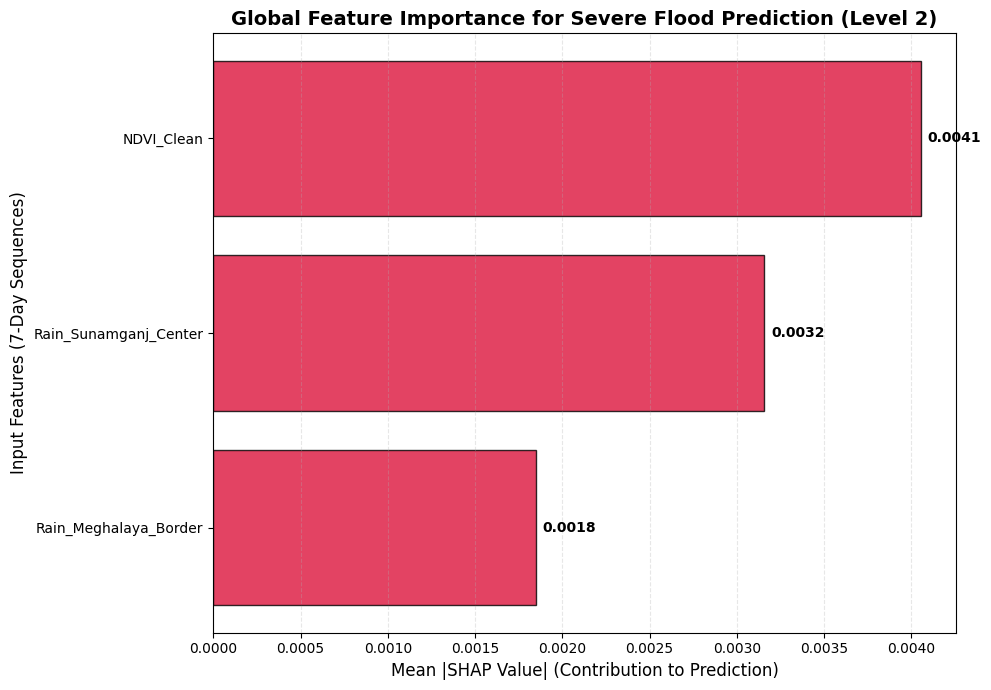

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# 1. Feature List (Must match the order used during training)
feature_cols = [
    "NDVI_Clean", "Rain_Sunamganj_Center", "Rain_Meghalaya_Border",
    "Daily_Water_Level", "Soil_Moisture", "Temperature", "Radar_VV"
]

# 2. Setup Explainer for LSTM
# Note: LSTMs are sensitive to background size. 100-200 samples is a good balance for speed/accuracy.
# We use the X_train to set the baseline expectations for the model.
background = X_train[np.random.choice(X_train.shape[0], 150, replace=False)]
explainer = shap.GradientExplainer(model_lstm, background) # Changed to model_lstm

# 3. Calculate SHAP values for the Test Set
# We explain the first 100 samples to get a statistically significant average
shap_values = explainer.shap_values(X_test[:100])

# 4. Extract Global Importance for Class 2 (Severe Risk)
# shap_values[2] shape is (samples, 7, 7) -> (100 samples, 7 days, 7 features)
# We take the mean of the absolute values across samples and time steps.
feature_importance = np.abs(shap_values[2]).mean(axis=(0, 1))

# 5. Create IEEE-Style Professional Plot
plt.figure(figsize=(10, 7))

# Sort features by importance
indices = np.argsort(feature_importance)
sorted_features = [feature_cols[i] for i in indices]
sorted_importance = feature_importance[indices]

# Color coding for your paper (Blues for Hydrology, Greens for Agriculture)
colors = ['#2c3e50' if 'Rain' in f or 'Water' in f else '#27ae60' for f in sorted_features]
plt.barh(sorted_features, sorted_importance, color='crimson', edgecolor='black', alpha=0.8)

# Formatting
plt.title('Global Feature Importance for Severe Flood Prediction (Level 2)', fontsize=14, fontweight='bold')
plt.xlabel('Mean |SHAP Value| (Contribution to Prediction)', fontsize=12)
plt.ylabel('Input Features (7-Day Sequences)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)

# Add value labels to the end of each bar
for i, v in enumerate(sorted_importance):
    plt.text(v + (max(sorted_importance)*0.01), i, f"{v:.4f}", color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_32
Received: inputs=['Tensor(shape=(70, 7, 7))']
  warnings.warn(msg)


Verified SHAP Plotting Shape: (70, 7)
Verified Data Plotting Shape: (70, 7)


/tmp/ipython-input-603208767.py:34: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


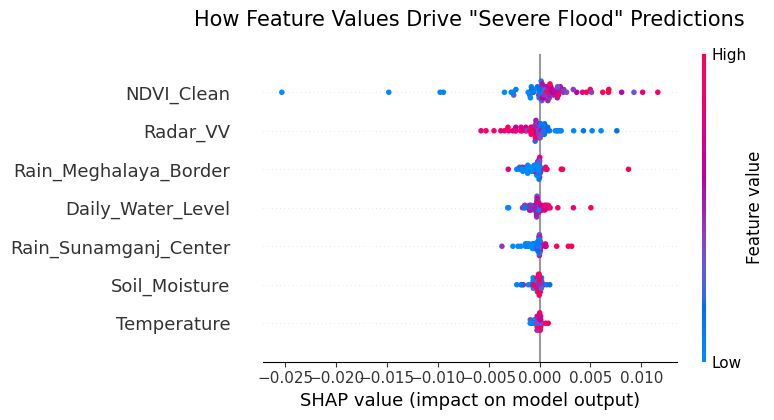

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# 1. Select a small subset for calculation (LSTMs are heavy)
num_samples = 70
X_subset = X_test[:num_samples]

# 2. Calculate SHAP values
# Note: explainer.shap_values might return a list OR a 4D array depending on your TF version
shap_values = explainer.shap_values(X_subset)

# 3. FIX: Check if shap_values is a list or an array and extract Class 2 correctly
if isinstance(shap_values, list):
    # If it's a list, index [2] is Class 2 (Severe)
    # Shape: (70, 7, 7)
    class_2_shap = shap_values[2]
else:
    # If it's a 4D array, the last dimension is the class. Use [..., 2] for Class 2
    # Shape: (70, 7, 7)
    class_2_shap = shap_values[:, :, :, 2]

# 4. Average across the 7-day time dimension for the Global Summary Plot
# We want to see how each feature generally impacts the outcome over the whole week
shap_values_to_plot = class_2_shap.mean(axis=1)  # Result: (70, 7)
features_to_plot = X_subset.mean(axis=1)         # Result: (70, 7)

# --- DEBUG PRINT ---
print(f"Verified SHAP Plotting Shape: {shap_values_to_plot.shape}")
print(f"Verified Data Plotting Shape: {features_to_plot.shape}")

# 5. Generate the Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_to_plot,
    features_to_plot,
    feature_names=feature_cols,
    plot_type="dot",
    show=False
)

plt.title('How Feature Values Drive "Severe Flood" Predictions', fontsize=15, pad=20)
plt.tight_layout()
plt.show()

In [ ]:

# 4. Final Accuracy Score
test_loss, test_acc = model_lstm.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Accuracy: {test_acc:.4f}")


Final Test Accuracy: 0.9589


**LeadTime**

Plots saved as ieee_confusion_matrix.pdf and ieee_confusion_matrix.png


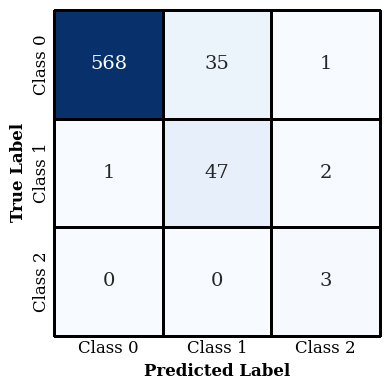

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Data Preparation ---
# The raw confusion matrix from your output
cm_data = np.array([
    [568, 35,  1],
    [  1, 47,  2],
    [  0,  0,  3]
])

# Define class labels.
# Since your report only shows 0, 1, 2, we use those.
# IF you have real names (e.g., ['Normal', 'Benign', 'Malignant']), replace them here.
class_names = ['Class 0', 'Class 1', 'Class 2']

# --- 2. Plot Formatting for IEEE ---
# Set publication-quality settings.
# Using a serif font often blends well with IEEE LaTeX templates.
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
# Ensure text is large enough to read when scaled down in a paper column
LABEL_SIZE = 12
annot_kws = {"size": 14} # Size of the numbers inside the boxes

# Setup figure size.
# A typical single column width in IEEE is roughly 3.5 inches.
# We make it square for a confusion matrix.
fig, ax = plt.subplots(figsize=(4, 4))

# --- 3. Create the Heatmap ---
# Use Seaborn to generate the heatmap
# cmap='Blues': A professional, monochrome-friendly color scale.
# fmt='d': Ensures numbers are displayed as integers (not scientific notation).
# cbar=False: Removing colorbar to save space, as the numbers are distinct.
sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor='black', clip_on=False,
            cbar=False, ax=ax, annot_kws=annot_kws, square=True)

# --- 4. Labeling and Refinement ---
# Label axes
ax.set_xlabel('Predicted Label', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('True Label', fontsize=LABEL_SIZE, fontweight='bold')

# Format tick labels
ax.tick_params(axis='both', which='major', labelsize=LABEL_SIZE)

# Remove tick marks for a cleaner look, keep labels
ax.tick_params(length=0)

# Ensure the plot layout is tight so labels aren't cut off
plt.tight_layout()

# --- 5. Save the Image ---
# Save in high resolution (300+ DPI) for publication.
# .pdf or .eps are ideal for LaTeX papers as they are vector formats that scale infinitely.
# .png is good for drafting or web viewing.
output_filename = 'ieee_confusion_matrix'
plt.savefig(f'{output_filename}.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{output_filename}.png', dpi=300, bbox_inches='tight')
# plt.savefig(f'{output_filename}.eps', dpi=300, bbox_inches='tight', format='eps') # Uncomment if EPS needed

print(f"Plots saved as {output_filename}.pdf and {output_filename}.png")
plt.show()

**LSTM LeadTime 7  SEQ_len 14 and lead_Time =7**

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# --- ১. ডেটা প্রিপারেশন ---
df = pd.read_csv('/content/sample_data/Agro_pulsedataset(verified).csv')

feature_cols = [
    "NDVI_Clean", "Rain_Sunamganj_Center", "Rain_Meghalaya_Border",
    "Daily_Water_Level", "Soil_Moisture", "Temperature", "Radar_VV"
]
target_col = "Final_AgroPulse_Level"

# মিসিং ভ্যালু পূরণ
df[feature_cols] = df[feature_cols].interpolate().fillna(method='bfill')

# স্কেলিং
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

# --- ২. লিড টাইম লজিক (7-Day Lead Prediction) ---
SEQ_LEN = 14    # গত ৭ দিনের ডেটা ইনপুট হিসেবে নিবে
LEAD_TIME = 7  # ৭ দিন পরের অবস্থা প্রেডিক্ট করার জন্য গ্যাপ

def create_7day_lead_sequences(data, target, seq_len, lead_time):
    X, y = [], []
    # লজিক: i থেকে i+seq_len পর্যন্ত ইনপুট, i+seq_len+lead_time-1 এ টার্গেট
    for i in range(len(data) - seq_len - lead_time + 1):
        X.append(data[i : i + seq_len])
        y.append(target[i + seq_len + lead_time - 1])
    return np.array(X), np.array(y)

X, y = create_7day_lead_sequences(df[feature_cols].values, df[target_col].values, SEQ_LEN, LEAD_TIME)

# ট্রেন-টেস্ট স্প্লিট (ব্যালেন্স রাখার জন্য stratify ব্যবহার করা হয়েছে)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

# --- ৩. মডিফাইড LSTM মডেল আর্কিটেকচার ---
num_classes = 3
final_weights = {0: 0.36248, 1: 4.37333, 2: 79.51515}

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10, # লিড টাইম প্রেডিকশন কঠিন, তাই পেশেন্স একটু বাড়ানো হয়েছে
    restore_best_weights=True
)

model_lstm = models.Sequential([
    layers.Input(shape=(SEQ_LEN, len(feature_cols))),

    # LSTM layer
    layers.LSTM(64, return_sequences=False),

    layers.Dropout(0.4),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# --- ৪. ট্রেনিং ---
history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=64,
    class_weight=final_weights,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100


/tmp/ipykernel_265/3841975268.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].interpolate().fillna(method='bfill')


49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3147 - loss: 0.9978 - val_accuracy: 0.6881 - val_loss: 0.9752
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6495 - loss: 1.0632 - val_accuracy: 0.7303 - val_loss: 0.7764
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6993 - loss: 0.8371 - val_accuracy: 0.7431 - val_loss: 0.6112
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7520 - loss: 0.5451 - val_accuracy: 0.7633 - val_loss: 0.5282
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7694 - loss: 0.5420 - val_accuracy: 0.7872 - val_loss: 0.5071
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7830 - loss: 0.5410 - val_accuracy: 0.8239 - val_loss: 0.4577
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8113 - loss: 0.4325 - val_accuracy: 0.8165 - val_loss: 0.4589
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8278 - loss: 0.3600 - val_accuracy: 0.7890 - val_loss: 

** **SEQ_len 14 and lead_Time =7**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# ১. ডেটা প্রসেসিং (এটি নিশ্চিত করবে যে X এবং y এর সাইজ সমান)
SEQ_LEN = 14
LEAD_TIME = 7

def create_final_sequences(data, target, seq_len, lead_time):
    X, y = [], []
    # এখানে loop টি নিশ্চিত করে যে lead time অনুযায়ী ডেটা শিফট হয়েছে
    for i in range(len(data) - seq_len - lead_time + 1):
        X.append(data[i : i + seq_len])
        y.append(target[i + seq_len + lead_time - 1])
    return np.array(X), np.array(y)

# ডেটা তৈরি করুন
X, y = create_final_sequences(df[feature_cols].values, df[target_col].values, SEQ_LEN, LEAD_TIME)

# ২. নতুন করে স্প্লিট করুন (এটি 546 বা 545 যাই হোক, X_test এবং y_test সমান হবে)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

# ৩. প্রেডিকশন নিন (অবশ্যই নতুন X_test ব্যবহার করে)
y_pred_probs = model_lstm.predict(X_test)
y_pred_default = np.argmax(y_pred_probs, axis=1)

# ৪. ইভালুয়েশন (এখন আর এরর আসবে না)
print("=== Performance WITHOUT Threshold ===")
print(classification_report(y_test, y_pred_default))

# কাস্টম থ্রেশহোল্ড চেক
def custom_predict(probs, threshold_level2=0.8, threshold_level1=0.6):
    predictions = []
    for p in probs:
        if p[2] >= threshold_level2: predictions.append(2)
        elif p[1] >= threshold_level1: predictions.append(1)
        else: predictions.append(0)
    return np.array(predictions)

y_pred_custom = custom_predict(y_pred_probs)
print("\n=== Performance WITH Custom Threshold ===")
print(classification_report(y_test, y_pred_custom))

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
=== Performance WITHOUT Threshold ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       505
           1       0.73      0.97      0.83        38
           2       0.67      1.00      0.80         2

    accuracy                           0.97       545
   macro avg       0.80      0.98      0.87       545
weighted avg       0.98      0.97      0.97       545


=== Performance WITH Custom Threshold ===
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       505
           1       0.75      0.95      0.84        38
           2       0.00      0.00      0.00         2

    accuracy                           0.97       545
   macro avg       0.58      0.64      0.61       545
weighted avg       0.97      0.97      0.97       545



**এই কোডটি যেভাবে কাজ করে (Workflow):
এই কোডটি মূলত Stratified 14-Fold Cross-Validation এর একটি পূর্ণাঙ্গ সাইকেল সম্পন্ন করে।

১. ডেটা বিভাজন (Splitting): skf.split(X, y) এর মাধ্যমে আপনার পুরো ডেটাসেটকে ১৪টি সমান ভাগে বা 'ফোল্ডে' ভাগ করা হয়। 'Stratified' হওয়ার কারণে প্রতিটি ভাগে Level 0, 1, এবং 2 এর অনুপাত মূল ডেটাসেটের মতোই রাখা হয় ।
২. নতুন মডেল শুরু (Fresh Start): লুপের ভেতরে build_model() কল করার মাধ্যমে প্রতিবার একটি একদম নতুন (Fresh) মডেল তৈরি হয়। এটি নিশ্চিত করে যে মডেলটি আগের ফোল্ডের কোনো তথ্য মনে রাখছে না।
৩. ট্রেনিং (Training): model_lstm.fit() লাইনের মাধ্যমে মডেলটি ১৪টি ভাগের মধ্যে ১৩টি ভাগ (Train Index) ব্যবহার করে নিজেকে তৈরি বা 'লার্ন' করে ।
৪. টেস্টিং (Testing/Validation): এরপর মডেলটি যে অংশটি কখনো দেখেনি (বাকি ১টি ভাগ বা Test Index), সেটির ওপর প্রেডিকশন চালায় ।
৫. ফলাফল সংগ্রহ (Aggregation): প্রতিবার লুপ ঘোরার সময় টেস্ট রেজাল্টগুলো all_y_true এবং all_y_pred লিস্টে জমা হয়।**

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np

# ১. মডেল তৈরির ফাংশন (প্রতি ফোল্ডে নতুন করে শুরু করার জন্য)
def build_model():
    model = models.Sequential([
        layers.Input(shape=(SEQ_LEN, len(feature_cols))),
        layers.LSTM(64, return_sequences=False),
        layers.Dropout(0.4),
        layers.Dense(32, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# ২. ক্রস-ভ্যালিডেশন সেটআপ
skf = StratifiedKFold(n_splits=14, shuffle=True, random_state=42)

# সব ফোল্ডের প্রেডিকশন জমা রাখার লিস্ট
all_y_true = []
all_y_pred = []
fold_accuracies = []

# ৩. লুপ শুরু
for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    print(f"\n" + "="*20 + f" FOLD {i+1} " + "="*20)

    X_train_fold, X_val_fold = X[train_index], X[test_index]
    y_train_fold, y_val_fold = y[train_index], y[test_index]

    # নতুন মডেল বিল্ড এবং ট্রেইন
    model_lstm = build_model()
    model_lstm.fit(X_train_fold, y_train_fold, epochs=100, batch_size=64,
                   class_weight=final_weights, verbose=0) # ভেরবোস ০ দিলে ল্যাগ কম হবে

    # প্রোবাবিলিটি বের করা
    y_pred_probs = model_lstm.predict(X_val_fold)

    # কাস্টম থ্রেশহোল্ড প্রয়োগ (আপনার ফাংশন)
    y_pred_custom = custom_predict(y_pred_probs)

    # রেজাল্ট জমা রাখা
    all_y_true.extend(y_val_fold)
    all_y_pred.extend(y_pred_custom)

    acc = accuracy_score(y_val_fold, y_pred_custom)
    fold_accuracies.append(acc)
    print(f"Fold {i+1} Accuracy: {acc * 100:.2f}%")

# ৪. ফাইনাল ইভ্যালুয়েশন (Q1 Paper Style)
print("\n" + "="*20 + " OVERALL PERFORMANCE REPORT " + "="*20)
target_names = ['Level 0', 'Level 1', 'Level 2']

# এটি আপনাকে সব ফোল্ডের গড় পারফরম্যান্স দিবে (যা পেপারে রিপোর্ট করবেন)
print(classification_report(all_y_true, all_y_pred, target_names=target_names))

print(f"Mean Accuracy: {np.mean(fold_accuracies) * 100:.2f}%")
print(f"Standard Deviation: {np.std(fold_accuracies) * 100:.2f}%")


==================== FOLD 1 ====================
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Fold 1 Accuracy: 98.85%

==================== FOLD 2 ====================
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Fold 2 Accuracy: 97.69%

==================== FOLD 3 ====================
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Fold 3 Accuracy: 95.77%

==================== FOLD 4 ====================
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Fold 4 Accuracy: 96.15%

==================== FOLD 5 ====================
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Fold 5 Accuracy: 98.85%

==================== FOLD 6 ====================
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Fold 6 Accuracy: 95.00%

==================== FOLD 7 ====================
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Fold 7 Accuracy: 96.54%

==================== FOLD 8 ====================
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Fold 8 Accuracy: 94.98%

==================== FOLD 9 ====================
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Fold 9 Accuracy:

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# ১. প্রোবাবিলিটি বের করা
y_pred_probs = model_lstm.predict(X_test)

# ২. ডিফল্ট প্রেডিকশন (Argmax)
y_pred_default = np.argmax(y_pred_probs, axis=1)

# ৩. কাস্টম থ্রেশহোল্ড প্রেডিকশন ফাংশন
def custom_predict(probs, threshold_level2=0.8, threshold_level1=0.6):
    predictions = []
    for p in probs:
        if p[2] >= threshold_level2:
            predictions.append(2)
        elif p[1] >= threshold_level1:
            predictions.append(1)
        else:
            predictions.append(0)
    return np.array(predictions)

y_pred_custom = custom_predict(y_pred_probs)

# --- রিপোর্ট প্রিন্ট করা ---
target_names = ['Level 0', 'Level 1', 'Level 2']

print("="*50)
print("=== Performance WITHOUT Threshold (Default) ===")
print("="*50)
print(classification_report(y_test, y_pred_default, target_names=target_names))
acc_default = accuracy_score(y_test, y_pred_default)
print(f"Overall Accuracy (Default): {acc_default * 100:.2f}%")

print("\n" + "="*50)
print("=== Performance WITH Custom Threshold (Optimized) ===")
print("="*50)
print(classification_report(y_test, y_pred_custom, target_names=target_names))
acc_custom = accuracy_score(y_test, y_pred_custom)
print(f"Overall Accuracy (Custom): {acc_custom * 100:.2f}%")

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
=== Performance WITHOUT Threshold (Default) ===
              precision    recall  f1-score   support

     Level 0       1.00      0.97      0.98       505
     Level 1       0.70      1.00      0.83        38
     Level 2       0.67      1.00      0.80         2

    accuracy                           0.97       545
   macro avg       0.79      0.99      0.87       545
weighted avg       0.98      0.97      0.97       545

Overall Accuracy (Default): 96.88%

=== Performance WITH Custom Threshold (Optimized) ===
              precision    recall  f1-score   support

     Level 0       1.00      0.97      0.98       505
     Level 1       0.73      1.00      0.84        38
     Level 2       1.00      0.50      0.67         2

    accuracy                           0.97       545
   macro avg       0.91      0.82      0.83       545
weighted avg       0.98      0.97      0.97       545

Overall Accuracy (Custom): 97.25%


**যেহেতু আপনার Level 2-তে মাত্র ২টি স্যাম্পল আছে, সাধারণ ৫-ফোল্ড বা ১০-ফোল্ড ক্রস-ভ্যালিডেশন এখানে কাজ করবে না (কারণ প্রতিটি ফোল্ডে অন্তত ১টি করে স্যাম্পল থাকতে হবে)। আপনার ক্ষেত্রে Stratified 2-Fold ব্যবহার করা সবচেয়ে নিরাপদ।(LSTM)**

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# ১. ক্রস-ভ্যালিডেশন সেটআপ (n_splits=2 কারণ Level 2-তে মাত্র ২টা স্যাম্পল আছে)
skf = StratifiedKFold(n_splits=14, shuffle=True, random_state=42)

# রেজাল্ট স্টোর করার জন্য লিস্ট
fold_accuracies = []

# ২. লুপ শুরু (ডাটাকে ২ ভাগে ভাগ করে টেস্ট করা হবে)
for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    print(f"\n" + "="*20 + f" FOLD {i+1} " + "="*20)

    # ডাটা স্প্লিট করা (X এবং y আপনার অরিজিনাল ডাটা হতে হবে)
    X_train_fold, X_val_fold = X[train_index], X[test_index]
    y_train_fold, y_val_fold = y[train_index], y[test_index]

    # আপনার মডেলটি এখানে নতুন করে ডিফাইন এবং কম্পাইল করতে হবে
    # model_lstm = build_your_model()

    # মডেল ট্রেইন করা (Class Weight সহ)
    # model_lstm.fit(X_train_fold, y_train_fold, class_weight=your_weights, epochs=..., batch_size=...)

    # ৩. প্রোবাবিলিটি বের করা
    y_pred_probs = model_lstm.predict(X_val_fold)

    # ৪. আপনার কাস্টম থ্রেশহোল্ড ফাংশন (আগের মতোই)
    def custom_predict(probs, threshold_level2=0.8, threshold_level1=0.6):
        predictions = []
        for p in probs:
            if p[2] >= threshold_level2:
                predictions.append(2)
            elif p[1] >= threshold_level1:
                predictions.append(1)
            else:
                predictions.append(0)
        return np.array(predictions)

    y_pred_custom = custom_predict(y_pred_probs)

    # ৫. রিপোর্ট প্রিন্ট করা
    target_names = ['Level 0', 'Level 1', 'Level 2']
    print(classification_report(y_val_fold, y_pred_custom, target_names=target_names))

    acc = accuracy_score(y_val_fold, y_pred_custom)
    fold_accuracies.append(acc)
    print(f"Fold {i+1} Accuracy: {acc * 100:.2f}%")

# ৬. গড় একুরেসি (Average Performance)
print("\n" + "="*50)
print(f"Average Accuracy across all folds: {np.mean(fold_accuracies) * 100:.2f}%")


==================== FOLD 1 ====================
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
              precision    recall  f1-score   support

     Level 0       1.00      0.98      0.99       241
     Level 1       0.86      1.00      0.92        18
     Level 2       0.50      1.00      0.67         1

    accuracy                           0.98       260
   macro avg       0.79      0.99      0.86       260
weighted avg       0.99      0.98      0.99       260

Fold 1 Accuracy: 98.46%

==================== FOLD 2 ====================
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
              precision    recall  f1-score   support

     Level 0       1.00      0.98      0.99       241
     Level 1       0.78      1.00      0.88        18
     Level 2       0.50      1.00      0.67         1

    accuracy                           0.98       260
   macro avg       0.76      0.99      0.84       260
weighted avg       0.98      0.98      0.98       260

Fold 2 Accuracy: 97.69%

=============

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
              precision    recall  f1-score   support

     Level 0       1.00      0.98      0.99       240
     Level 1       0.78      1.00      0.88        18
     Level 2       1.00      1.00      1.00         1

    accuracy                           0.98       259
   macro avg       0.93      0.99      0.96       259
weighted avg       0.98      0.98      0.98       259

Fold 11 Accuracy: 98.07%

==================== FOLD 12 ====================
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
              precision    recall  f1-score   support

     Level 0       1.00      0.97      0.98       240
     Level 1       0.69      1.00      0.82        18
     Level 2       1.00      1.00      1.00         1

    accuracy                           0.97       259
   macro avg       0.90      0.99      0.93       259
weighted avg       0.98      0.97      0.97       259

Fold 12 Accuracy: 96.91%

==================== FOLD 13 ====================
9/9 ━━━━━━

**BILSTM leadtime 7**

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ১. ডেটা লোড এবং ফিচার সিলেকশন
df = pd.read_csv('/content/sample_data/Agro_pulsedataset(verified).csv')

feature_cols = [
    "NDVI_Clean", "Rain_Sunamganj_Center", "Rain_Meghalaya_Border",
    "Daily_Water_Level", "Soil_Moisture", "Temperature", "Radar_VV"
]
target_col = "Final_AgroPulse_Level"

# মিসিং ভ্যালু হ্যান্ডেলিং (টাইম সিরিজ ডেটার জন্য ইন্টারপোলেশন সেরা)
df[feature_cols] = df[feature_cols].interpolate(method='linear').fillna(method='bfill')

# ফিচার স্কেলিং
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

# ২. সিকোয়েন্স তৈরি (৭ দিন আগের প্রেডিকশন লজিক)
SEQ_LEN = 14
LEAD_TIME = 7  # ৭ দিন আগের পূর্বাভাস দেওয়ার জন্য

def create_advanced_sequences(data, target, seq_len, lead_time):
    X, y = [], []
    for i in range(len(data) - seq_len - lead_time + 1):
        # বর্তমান দিন পর্যন্ত তথ্য (SEQ_LEN পরিমাণ)
        X.append(data[i : i + seq_len])
        # ঠিক ৭ দিন পরের রেজাল্ট (Lead Time)
        y.append(target[i + seq_len + lead_time - 1])
    return np.array(X), np.array(y)

X, y = create_advanced_sequences(df[feature_cols].values, df[target_col].values, SEQ_LEN, LEAD_TIME)

# ট্রেন-টেস্ট স্প্লিট (টাইম সিরিজ বজায় রেখে)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

# ৩. BiLSTM মডেল আর্কিটেকচার
num_classes = len(np.unique(y))
final_weights = {0: 0.36, 1: 4.37, 2: 79.51} # আপনার দেওয়া ওয়েট

model_bilstm = models.Sequential([
    layers.Input(shape=(SEQ_LEN, len(feature_cols))),

    # ১ম BiLSTM লেয়ার: তথ্য রিফাইনমেন্টের জন্য
    layers.Bidirectional(layers.LSTM(128, return_sequences=True)),
    layers.Dropout(0.3),

    # ২য় BiLSTM লেয়ার: গ্লোবাল প্যাটার্ন বোঝার জন্য
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dropout(0.3),

    # ডেন্স লেয়ার (লজিক্যাল ডিসিশন মেকিং)
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

# ৪. কম্পাইল এবং ট্রেনিং
optimizer = optimizers.Adam(learning_rate=0.0005)
model_bilstm.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history = model_bilstm.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    class_weight=final_weights,
    callbacks=[early_stopping],
    verbose=1
)

/tmp/ipykernel_595/1981659645.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].interpolate(method='linear').fillna(method='bfill')


Epoch 1/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 37s 73ms/step - accuracy: 0.6292 - loss: 0.9764 - val_accuracy: 0.7339 - val_loss: 0.8173
Epoch 2/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.6677 - loss: 0.6725 - val_accuracy: 0.7028 - val_loss: 0.6786
Epoch 3/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.7526 - loss: 0.6346 - val_accuracy: 0.7046 - val_loss: 0.5646
Epoch 4/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.7646 - loss: 0.5507 - val_accuracy: 0.7523 - val_loss: 0.5007
Epoch 5/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.7668 - loss: 0.6089 - val_accuracy: 0.8275 - val_loss: 0.4206
Epoch 6/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.7853 - loss: 0.5178 - val_accuracy: 0.8477 - val_loss: 0.3731
Epoch 7/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.8093 - loss: 0.3851 - val_accuracy: 0.7651 - val_loss: 0.5778
Epoch 8/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.7766 - loss: 0.4071 - val_accuracy: 

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step
Detailed Performance Report:

                                  precision    recall  f1-score   support

               Level 0: No Flood       0.99      0.96      0.97       505
    Level 1: Minor Flood/Growing       0.60      0.89      0.72        38
Level 2: Critical (Mature+Flood)       1.00      0.50      0.67         2

                        accuracy                           0.95       545
                       macro avg       0.86      0.78      0.79       545
                    weighted avg       0.96      0.95      0.95       545

Overall Accuracy: 95.05%


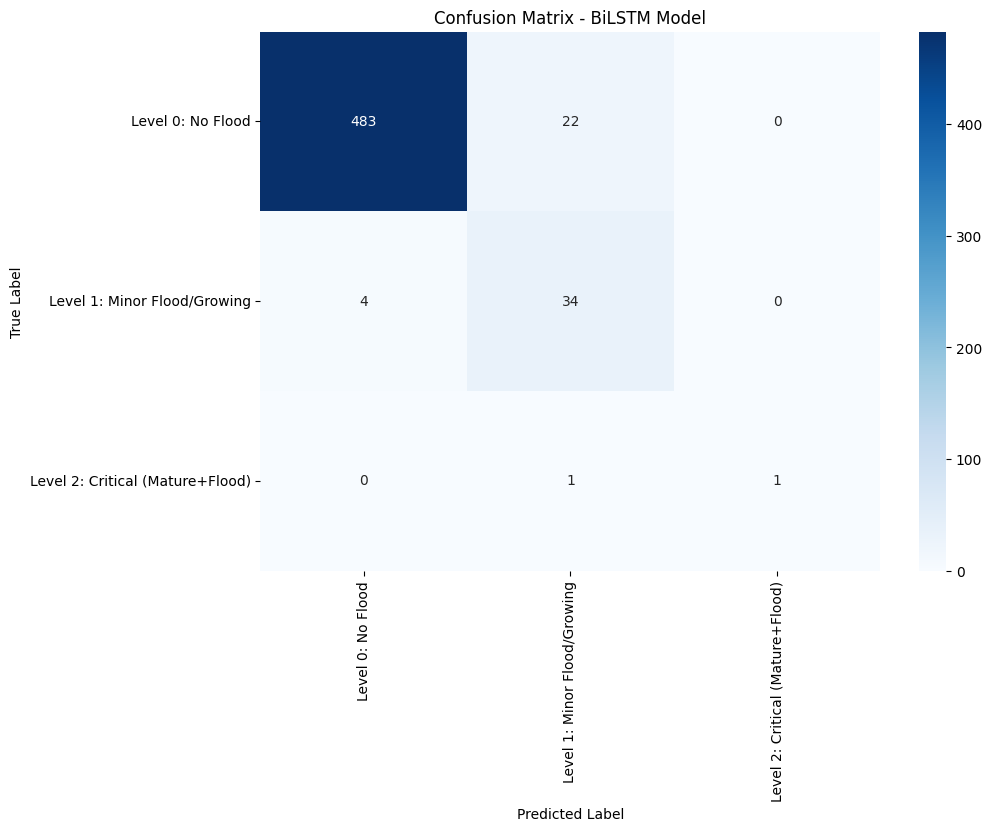

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ১. টেস্ট ডেটার ওপর প্রেডিকশন নেওয়া
y_pred_probs = model_bilstm.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# ২. ক্লাসের নামগুলো নির্ধারণ (আপনার ডেটা অনুযায়ী)
target_names = ['Level 0: No Flood', 'Level 1: Minor Flood/Growing', 'Level 2: Critical (Mature+Flood)']

# ৩. Classification Report তৈরি (Precision, Recall, F1, Macro & Weighted Avg)
report = classification_report(y_test, y_pred, target_names=target_names)
print("Detailed Performance Report:\n")
print(report)

# ৪. আলাদাভাবে নির্দিষ্ট মেট্রিক্সগুলো প্রিন্ট করা
acc = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {acc * 100:.2f}%")

# ৫. Confusion Matrix (মডেল কোন ক্লাসকে কী ভুল প্রেডিক্ট করছে তা দেখার জন্য)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - BiLSTM Model')
plt.show()

Threshold Tuning)
ডিফল্টভাবে মডেলটি যে ক্লাসের প্রোবাবিলিটি (Probability) সবচেয়ে বেশি (যেমন ০.৫০ এর বেশি), সেটিকেই প্রেডিক্ট করে। False Alarm কমাতে আমরা Level 1 বা Level 2 এর জন্য থ্রেশহোল্ড বাড়িয়ে দিতে পারি (যেমন ০.৭০ বা ০.৮০)। এতে মডেল যখন একদম নিশ্চিত হবে, তখনই কেবল অ্যালার্ম দেবে।

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
--- Default (Argmax) Performance ---
                                  precision    recall  f1-score   support

               Level 0: No Flood       0.99      0.96      0.97       505
          Level 1: Minor/Growing       0.60      0.89      0.72        38
Level 2: Critical (Mature+Flood)       1.00      0.50      0.67         2

                        accuracy                           0.95       545
                       macro avg       0.86      0.78      0.79       545
                    weighted avg       0.96      0.95      0.95       545


--- Optimized (Custom Threshold) Performance ---
                                  precision    recall  f1-score   support

               Level 0: No Flood       0.99      0.97      0.98       505
          Level 1: Minor/Growing       0.65      0.87      0.74        38
Level 2: Critical (Mature+Flood)       1.00      0.50      0.67         2

                        accuracy                      

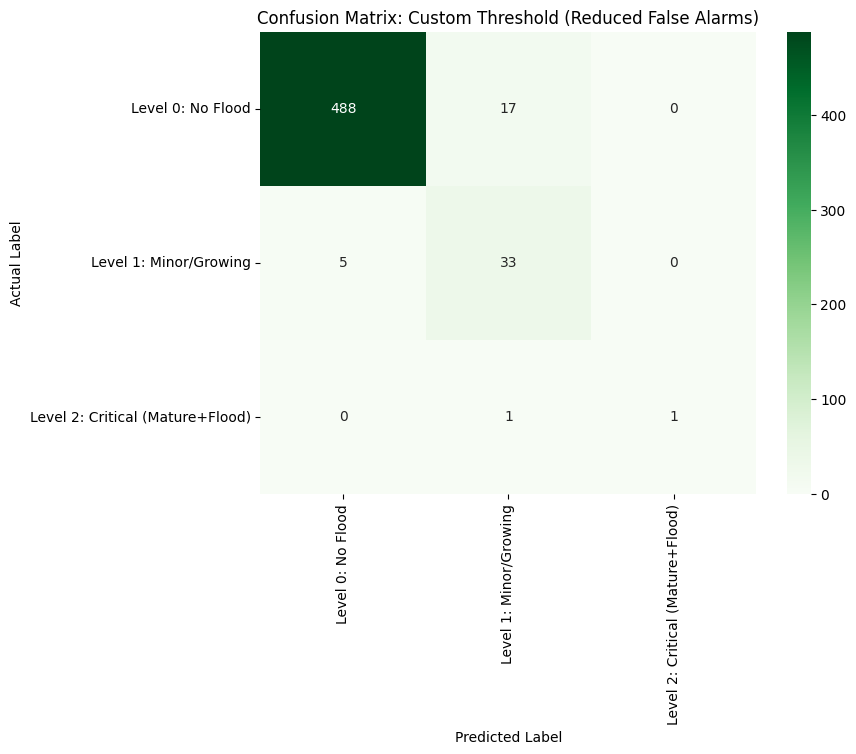

Final Accuracy after Optimization: 95.78%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ১. প্রোবাবিলিটি বের করা (Test Set এর ওপর)
# এটি প্রতিটি ক্লাসের জন্য ০ থেকে ১ এর মধ্যে একটি মান দেয়
y_pred_probs = model_bilstm.predict(X_test)

# ২. কাস্টম থ্রেশহোল্ড ফাংশন (False Alarm কমানোর লজিক)
def custom_predict(probs, threshold_level2=0.8, threshold_level1=0.6):
    """
    probs: মডেলের দেওয়া প্রোবাবিলিটি আউটপুট
    threshold_level2: Level 2 প্রেডিক্ট করতে হলে অন্তত কতটুকু নিশ্চিত হতে হবে (৮০%)
    threshold_level1: Level 1 প্রেডিক্ট করতে হলে অন্তত কতটুকু নিশ্চিত হতে হবে (৬০%)
    """
    predictions = []
    for p in probs:
        # প্রথমে সবচেয়ে ক্রিটিকাল কেস (Level 2) চেক করবে
        if p[2] >= threshold_level2:
            predictions.append(2)
        # তারপর মাইনর ফ্লাড (Level 1) চেক করবে
        elif p[1] >= threshold_level1:
            predictions.append(1)
        # কোনো থ্রেশহোল্ড পার না করলে নো ফ্লাড (Level 0)
        else:
            predictions.append(0)
    return np.array(predictions)

# ৩. কাস্টম প্রেডিকশন জেনারেট করা
# আপনি এখানে মান কমিয়ে বাড়িয়ে (যেমন ০.৭ বা ০.৯) রেজাল্ট চেক করতে পারেন
y_pred_custom = custom_predict(y_pred_probs, threshold_level2=0.80, threshold_level1=0.60)

# ৪. ডিফল্ট প্রেডিকশন (Argmax) তুলনা করার জন্য
y_pred_default = np.argmax(y_pred_probs, axis=1)

# ৫. পারফরম্যান্স রিপোর্ট দেখা
target_names = ['Level 0: No Flood', 'Level 1: Minor/Growing', 'Level 2: Critical (Mature+Flood)']

print("--- Default (Argmax) Performance ---")
print(classification_report(y_test, y_pred_default, target_names=target_names))

print("\n--- Optimized (Custom Threshold) Performance ---")
print(classification_report(y_test, y_pred_custom, target_names=target_names))

# ৬. Confusion Matrix ভিজ্যুয়ালাইজেশন
cm_custom = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: Custom Threshold (Reduced False Alarms)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# ৭. সেভ করা বা প্রিন্ট করা
final_acc = accuracy_score(y_test, y_pred_custom)
print(f"Final Accuracy after Optimization: {final_acc * 100:.2f}%")

২. Focal Loss ব্যবহার করা (Weights এর বিকল্প)
আপনি বর্তমানে class_weight ব্যবহার করছেন। এর পরিবর্তে Focal Loss ব্যবহার করলে মডেলটি শুধু ছোট ক্লাসকে গুরুত্বই দেয় না, বরং যে স্যাম্পলগুলো প্রেডিক্ট করা "কঠিন" (Hard examples) সেগুলোর ওপর বেশি ফোকাস করে। এটি False Alarm কমাতে ম্যাজিকের মতো কাজ করে।

**SMOTE সহ সম্পূর্ণ BiLSTM ট্রেনিং কোড**

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from collections import Counter

# ১. ডেটা লোড এবং ফিচার সিলেকশন
# আপনার ফাইল পাথ অনুযায়ী পরিবর্তন করুন
df = pd.read_csv('/content/sample_data/Agro_pulsedataset(verified).csv')

feature_cols = [
    "NDVI_Clean", "Rain_Sunamganj_Center", "Rain_Meghalaya_Border",
    "Daily_Water_Level", "Soil_Moisture", "Temperature", "Radar_VV"
]
target_col = "Final_AgroPulse_Level"

# মিসিং ভ্যালু হ্যান্ডেলিং
df[feature_cols] = df[feature_cols].interpolate(method='linear').ffill().bfill()

# ফিচার স্কেলিং
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

# ২. সিকোয়েন্স তৈরি (৭ দিন আগের প্রেডিকশন লজিক)
SEQ_LEN = 14
LEAD_TIME = 7

def create_advanced_sequences(data, target, seq_len, lead_time):
    X, y = [], []
    for i in range(len(data) - seq_len - lead_time + 1):
        X.append(data[i : i + seq_len])
        y.append(target[i + seq_len + lead_time - 1])
    return np.array(X), np.array(y)

X, y = create_advanced_sequences(df[feature_cols].values, df[target_col].values, SEQ_LEN, LEAD_TIME)

# ট্রেন-টেস্ট স্প্লিট (টেস্ট সেট সবসময় অরিজিনাল থাকবে)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

# --- ৩. SMOTE প্রয়োগ (টাইম সিরিজ ডেটার জন্য) ---
print(f"SMOTE-এর আগে ট্রেইনিং ডিস্ট্রিবিউশন: {Counter(y_train)}")

# ৩ডি ডেটাকে ২ডি-তে নেওয়া (Samples, SEQ_LEN * Features)
n_samples, n_timesteps, n_features = X_train.shape
X_train_flat = X_train.reshape(n_samples, n_timesteps * n_features)

# SMOTE কনফিগারেশন (k_neighbors কমিয়ে ৩ করা হয়েছে কারণ Level 2 এর ডেটা খুব কম)
smote = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=3)
X_train_resampled_flat, y_train_resampled = smote.fit_resample(X_train_flat, y_train)

# পুনরায় ৩ডি ফরমেটে রূপান্তর
X_train_final = X_train_resampled_flat.reshape(-1, n_timesteps, n_features)
y_train_final = y_train_resampled

print(f"SMOTE-এর পরে ট্রেইনিং ডিস্ট্রিবিউশন: {Counter(y_train_final)}")

# ৪. BiLSTM মডেল আর্কিটেকচার
num_classes = len(np.unique(y))

model_bilstm = models.Sequential([
    layers.Input(shape=(SEQ_LEN, n_features)),

    # ১ম BiLSTM লেয়ার
    layers.Bidirectional(layers.LSTM(128, return_sequences=True)),
    layers.Dropout(0.3),

    # ২য় BiLSTM লেয়ার
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dropout(0.3),

    # ডেন্স লেয়ার
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

# ৫. কম্পাইল এবং ট্রেনিং
optimizer = optimizers.Adam(learning_rate=0.0005)
model_bilstm.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# আর্লি স্টপিং (ওভারফিটিং রোধে)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=12, restore_best_weights=True
)

# ট্রেনিং শুরু (SMOTE করা ডেটা দিয়ে)
# যেহেতু SMOTE ডেটা ব্যালেন্স করে দিয়েছে, তাই Class Weight সব 1.0 রাখা হয়েছে
history = model_bilstm.fit(
    X_train_final, y_train_final,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# ৬. ইভালুয়েশন (Evaluation)
y_pred_probs = model_bilstm.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\n" + "="*30)
print("Classification Report (After SMOTE):")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

SMOTE-এর আগে ট্রেইনিং ডিস্ট্রিবিউশন: Counter({np.int64(0): 2864, np.int64(1): 212, np.int64(2): 12})
SMOTE-এর পরে ট্রেইনিং ডিস্ট্রিবিউশন: Counter({np.int64(0): 2864, np.int64(2): 2864, np.int64(1): 2864})
Epoch 1/100
269/269 ━━━━━━━━━━━━━━━━━━━━ 41s 79ms/step - accuracy: 0.8013 - loss: 0.5013 - val_accuracy: 0.9248 - val_loss: 0.2220
Epoch 2/100
269/269 ━━━━━━━━━━━━━━━━━━━━ 18s 67ms/step - accuracy: 0.9473 - loss: 0.1455 - val_accuracy: 0.9578 - val_loss: 0.0881
Epoch 3/100
269/269 ━━━━━━━━━━━━━━━━━━━━ 20s 73ms/step - accuracy: 0.9656 - loss: 0.1064 - val_accuracy: 0.9339 - val_loss: 0.1609
Epoch 4/100
269/269 ━━━━━━━━━━━━━━━━━━━━ 19s 69ms/step - accuracy: 0.9710 - loss: 0.0874 - val_accuracy: 0.9743 - val_loss: 0.0784
Epoch 5/100
269/269 ━━━━━━━━━━━━━━━━━━━━ 24s 82ms/step - accuracy: 0.9784 - loss: 0.0711 - val_accuracy: 0.9670 - val_loss: 0.1072
Epoch 6/100
269/269 ━━━━━━━━━━━━━━━━━━━━ 42s 86ms/step - accuracy: 0.9785 - loss: 0.0646 - val_accuracy: 0.9578 - val_loss: 0.1286
Epoch 7/1